In [1]:
import numpy as np
import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns
import string
from collections import Counter
import nltk
nltk.download('stopwords')
nltk.download('averaged_perceptron_tagger_eng')
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet
from nltk import pos_tag
import re
import json
import random
from nltk.sentiment.vader import SentimentIntensityAnalyzer
nltk.download('vader_lexicon')
import pycountry

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/samanalijayarathna/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /Users/samanalijayarathna/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /Users/samanalijayarathna/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


## Pre-processing

In [2]:
# Open the JSON file and load the data
with open('Datasets/combined_unique_reddit_posts.json', 'r') as file:
    reddit_data = json.load(file)

reddit_data = list(reddit_data['submissions'])

In [ ]:
country_aliases = {country.name.lower(): country.name for country in pycountry.countries}
custom_aliases = {
    "usa": "United States",
    "us": "United States",
    "u.s.": "United States",
    "u.s.a.": "United States",
    "america": "United States",
    "uk": "United Kingdom",
    "u.k": "United Kingdom",
    "uae": "United Arab Emirates",
    "south korea": "South Korea",
    "north korea": "North Korea",
    "vietnam": "Vietnam",
    "czech": "Czech Republic",
    "russia": "Russian Federation",
    "ivory coast": "Côte d'Ivoire",
    "oz": "Australia",
    "burma": "Myanmar",
    "holland": "Netherlands"
}

country_aliases.update(custom_aliases)

In [4]:
def get_wordnet_pos(treebank_tag):
    if treebank_tag.startswith('J'):
        return wordnet.ADJ
    elif treebank_tag.startswith('V'):
        return wordnet.VERB
    elif treebank_tag.startswith('N'):
        return wordnet.NOUN
    elif treebank_tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN

In [5]:
def processText(text, tokenizer, lemmatizer, stopwords, countries_aliases):
    """
    Perform tokenisation, normalisation (lower case and stemming) and stopword and twitter keyword removal.

    @param text: reddit submission or comment text
    @param tokenizer: tokeniser used.
    @param stemmer: stemmer used.
    @param stopwords: list of stopwords used

    @returns: a list of processed tokens
    """

    # covert all to lower case
    text = text.lower()
    # tokenise
    lTokens = tokenizer.tokenize(text)   
    # strip whitespaces
    lTokens = [token.strip() for token in lTokens]
    # normalize country name
    lTokens = [country_aliases.get(token, token) for token in lTokens]
    # lemmatize tokens
    taggedTokens = pos_tag(lTokens)
    lemmatizedTokens = set([lemmatizer.lemmatize(tok, get_wordnet_pos(pos)) for tok, pos in taggedTokens])
    # remove URL links
    regexHttp = re.compile("^http")

    # remove stopwords, digits
    return [tok for tok in lemmatizedTokens if tok not in stopwords and regexHttp.match(tok) == None and not tok.isdigit()]

In [6]:
tweetTokeniser = nltk.tokenize.TweetTokenizer()
lPunct = list(string.punctuation)
lStopwords = nltk.corpus.stopwords.words('english') + lPunct + ["via", "...", "’", "‘", "—", "”", "“", "–", "=/"]
lemmatizer = WordNetLemmatizer()

termFreqCounter = Counter()
reddit_tokens_list = []
countries_found = []
 
for submission in reddit_data:
    postTitle = submission['title']
    postBody = submission['selftext']
    date = pd.to_datetime(submission['created_utc'], unit='s')
    fullPost = postTitle + postBody
    lTokens = processText(text=fullPost, tokenizer=tweetTokeniser, lemmatizer=lemmatizer, stopwords=lStopwords, 
                          countries_aliases=country_aliases)
    reddit_tokens_list.append(
        {"date": date,
         "tokens": lTokens})
    termFreqCounter.update(lTokens)
    
    for comment in submission['comments']:
        commentBody = comment['body']
        date = pd.to_datetime(submission['created_utc'], unit='s')
        lTokens = processText(text=commentBody, tokenizer=tweetTokeniser, lemmatizer=lemmatizer, stopwords=lStopwords, 
                              countries_aliases=country_aliases)
        reddit_tokens_list.append(
            {"date": date,
             "tokens": lTokens})
        termFreqCounter.update(lTokens)

In [12]:
with open('reddit_tokens_list.json', 'w') as f:
    json.dump(reddit_tokens_list, f, default=str)

In [8]:
# number of most frequent terms to display
freqNum = 50

freqTerm = {}
counter = 1

for term, count in termFreqCounter.most_common(freqNum):
    print(term + ': ' + str(count))
    freqTerm[term] = count
    counter += 1

get: 29082
like: 28662
go: 27077
people: 20952
would: 19533
think: 19237
one: 18844
time: 18581
make: 18461
say: 17182
know: 16822
want: 16820
good: 14830
also: 14389
even: 14252
thing: 13877
see: 13519
take: 13326
year: 13010
really: 12097
need: 11714
way: 11464
much: 11300
day: 10666
country: 10163
well: 9910
family: 9616
come: 9614
United States: 9609
back: 9591
travel: 9487
never: 9445
work: 9402
could: 9267
try: 9252
life: 9242
feel: 9142
still: 9027
lot: 9009
find: 8791
friend: 8708
place: 8663
tell: 8518
give: 8413
look: 8356
love: 8207
someone: 8138
use: 7986
live: 7877
right: 7627


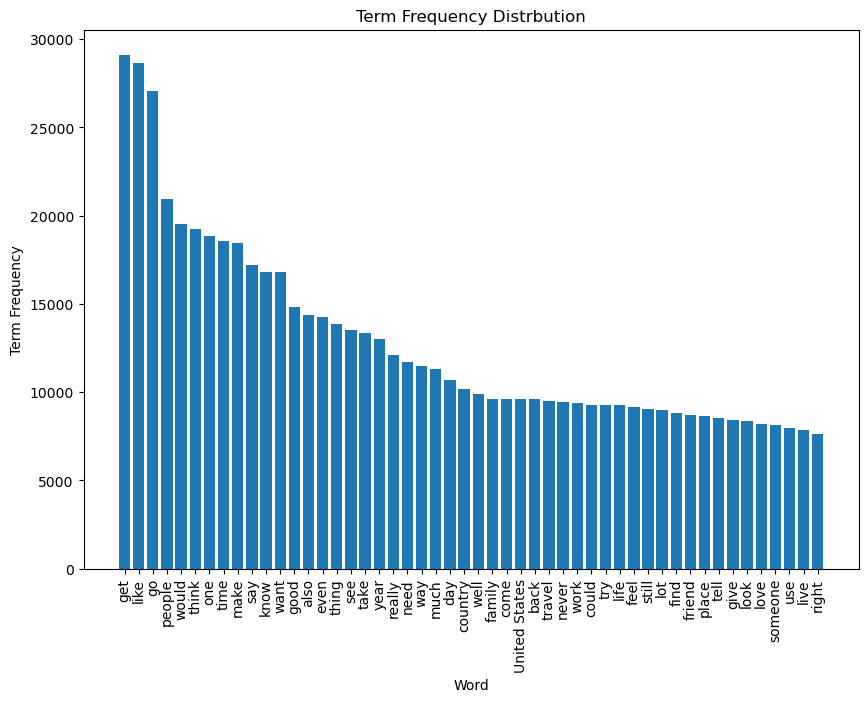

In [9]:
plt.figure(figsize=(10,7))
plt.bar(freqTerm.keys(), freqTerm.values())
plt.title("Term Frequency Distrbution")
plt.ylabel("Term Frequency")
plt.xlabel("Word")
plt.xticks(rotation = 90)
plt.show()

## Sentiment Analysis

In [10]:
def vaderPrintTokens(lTokens, dSentimentScores):
    """
    Print out the tokens and sentiment score.
    
    @param lTokens: List of tokens to print and colour.
    @dSentimentScores: Dictionary of sentiment from Vader.

    """
    print(*lTokens, sep=', ')
    for cat,score in dSentimentScores.items():
        print('{0}: {1}, '.format(cat, score), end='')
    print()

In [11]:
def vaderSentimentAnalysis(lTokens, bPrint):
    """
    Use Vader lexicons instead of a raw positive and negative word count.

    @param sTweetsFilename: name of input file containing a json formated tweet dump
    @param bPrint: whether to print the stream of tokens and sentiment.  Uses colorama to highlight sentiment words.
    @param tweetProcessor: TweetProcessing object, used to pre-process each tweet.

    @returns: list of tweets, in the format of [date, sentiment]
    """

    sentAnalyser = SentimentIntensityAnalyzer()


    lSentiment = []
        
    for tokens in lTokens:
        date = tokens['date']
        tokens = tokens['tokens']
        
        text = " ".join(tokens)
        dSentimentScores = sentAnalyser.polarity_scores(text)
        
        lSentiment.append([pd.to_datetime(date), dSentimentScores['compound']])

        if bPrint:
            vaderPrintTokens(tokens, dSentimentScores)

    return lSentiment

In [12]:
flag = False
lSentiment = vaderSentimentAnalysis(reddit_tokens_list, flag)

In [13]:
lSentiment[0][1]

0.9941

In [14]:
len(reddit_tokens_list)

165676

In [15]:
def extract_countries(tokens, country_aliases):
    countries_found = set()
    for token in tokens:
        if token in country_aliases.values():
            countries_found.add(token)
    return list(countries_found)

In [16]:
country_sentiment = []

for i, item in enumerate(reddit_tokens_list):
    tokens = item['tokens']
    sentiment = lSentiment[i][1]
    countries_found = extract_countries(tokens, country_aliases)
    country_sentiment.append({
        "country": countries_found,
        "sentiment": sentiment
    })

In [19]:
rows = []
for item in country_sentiment:
    sentiment = item['sentiment']
    countries = item['country']
    for country in countries:
        rows.append({'country': country, 'sentiment': sentiment})

country_sentiment_df = pd.DataFrame(rows)

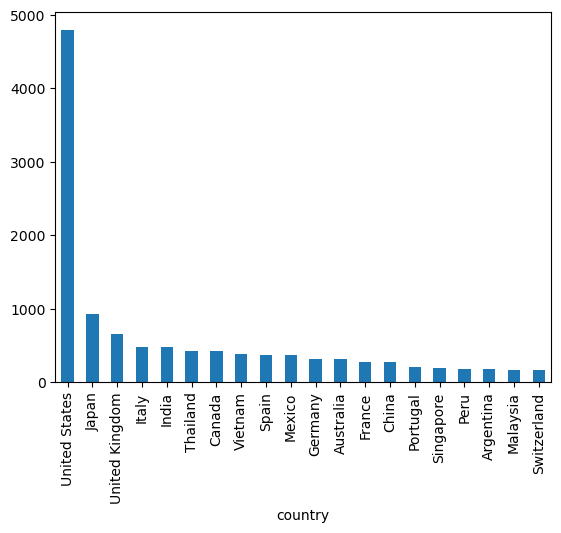

In [20]:
sentiment_by_country = country_sentiment_df.groupby('country')['sentiment'].sum()
sentiment_by_country.sort_values(ascending=False).head(20).plot(kind='bar')
plt.show()

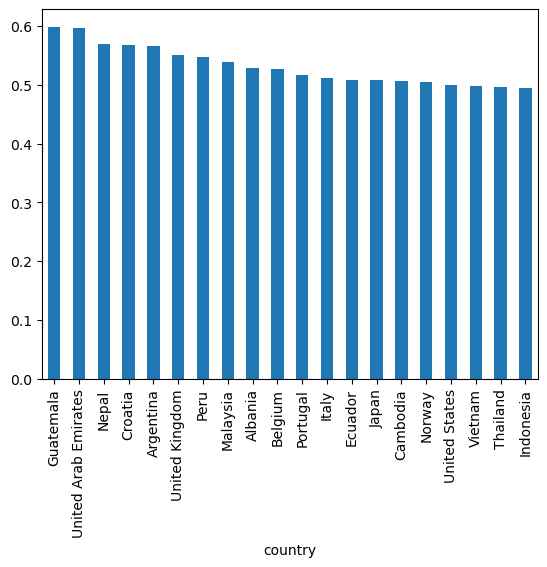

In [21]:
mentions = country_sentiment_df['country'].value_counts()
avg_sentiment = country_sentiment_df.groupby('country')['sentiment'].mean()
filtered = avg_sentiment[mentions > 100]  # only countries mentioned >100 times
filtered.sort_values(ascending=False).head(20).plot(kind='bar')
plt.show()

### Topic Modelling

In [40]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from wordcloud import WordCloud
import pyLDAvis
import pyLDAvis.sklearn

def extract_countries(tokens, country_aliases):
    return list({token for token in tokens if token in country_aliases.values()})

# Load structured list (with tokens + dates)
with open("reddit_tokens_list.json", "r") as f:
    reddit_tokens_list = json.load(f)

# Filter posts that mention at least one country
for tokens in reddit_tokens_list:
    countries = extract_countries(tokens, country_aliases)
    if countries:
        filtered_docs.append(" ".join(tokens))


lCombinedDocs = filtered_docs



/Users/samanalijayarathna/opt/anaconda3/lib/python3.8/site-packages/ipykernel/ipkernel.py:287: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [41]:
# Set LDA parameters
topicNum = 10
wordNumToDisplay = 15
featureNum = 2000

# Count vectorizer
tfVectorizer = CountVectorizer(max_df=0.95, min_df=2, max_features=featureNum, stop_words='english')
tf = tfVectorizer.fit_transform(lCombinedDocs)
tfFeatureNames = tfVectorizer.get_feature_names_out()

# Fit LDA model
ldaModel = LatentDirichletAllocation(
    n_components=topicNum,
    max_iter=10,
    learning_method='online',
    random_state=42
)
ldaModel.fit(tf)

/Users/samanalijayarathna/opt/anaconda3/lib/python3.8/site-packages/ipykernel/ipkernel.py:287: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


LatentDirichletAllocation(learning_method='online', random_state=42)

In [35]:
def display_topics(model, featureNames, numTopWords):
    for topicId, topicWeights in enumerate(model.components_):
        top_words = [featureNames[i] for i in topicWeights.argsort()[:-numTopWords - 1:-1]]
        print(f"\n Topic {topicId + 1}:")
        print("  ".join(top_words))

display_topics(ldaModel, tfFeatureNames, wordNumToDisplay)


 Topic 1:
nta  hope  husband  let  man  understand  change  know  wrong  sorry  say  people  american  mention  like

 Topic 2:
shit  money  pay  oh  use  buy  trump  house  work  save  wait  car  high  make  surprise

 Topic 3:
post  read  job  question  thanks  update  remove  contact  list  action  advice  sad  concern  ask  message

 Topic 4:
like  sound  tell  come  say  yeah  happen  right  need  believe  think  make  ex  know  sister

 Topic 5:
united  states  live  country  state  people  sense  world  big  small  important  come  normal  white  like

 Topic 6:
thank  honestly  choose  treat  adult  win  assume  hard  make  expensive  thought  hate  use  money  need

 Topic 7:
time  year  day  work  like  leave  long  home  away  make  start  stop  week  baby  month

 Topic 8:
kid  parent  child  family  relationship  fuck  comment  oop  wife  lol  dad  agree  delete  situation  support

 Topic 9:
time  travel  place  day  trip  like  absolutely  visit  great  city  year  coun

/Users/samanalijayarathna/opt/anaconda3/lib/python3.8/site-packages/ipykernel/ipkernel.py:287: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


/Users/samanalijayarathna/opt/anaconda3/lib/python3.8/site-packages/ipykernel/ipkernel.py:287: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


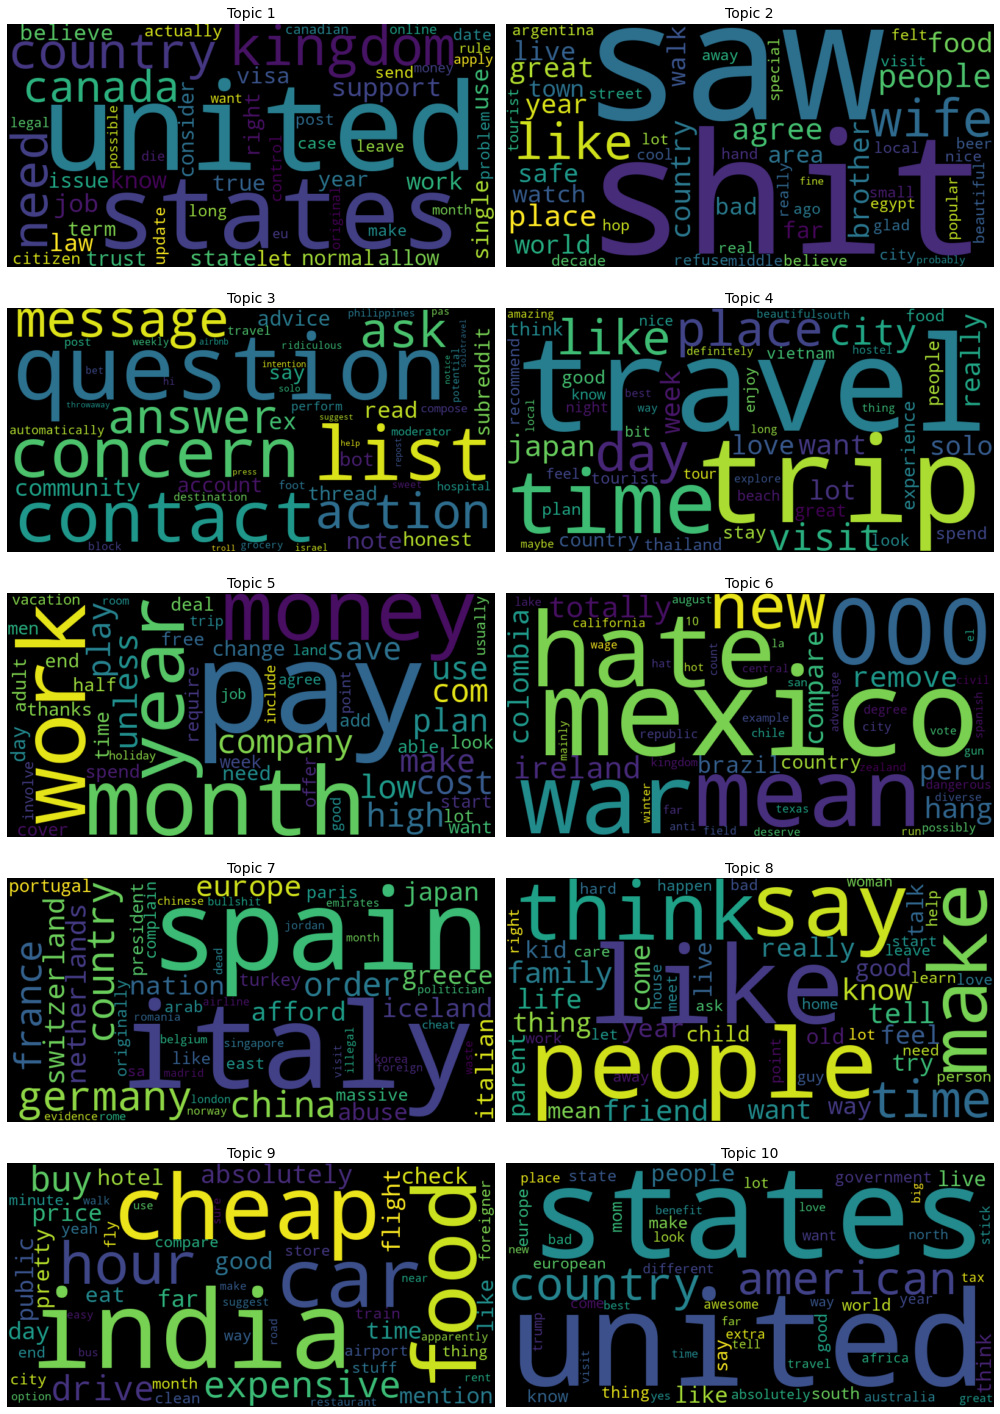

In [42]:
def displayWordcloud(model, featureNames, num_topics=10):
    normalized_weights = model.components_ / model.components_.sum(axis=1)[:, np.newaxis]
    cols = 2
    rows = (num_topics + 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(14, rows * 4))
    axes = axes.flatten()

    for topic_idx in range(num_topics):
        topic_words = {
            featureNames[i]: normalized_weights[topic_idx][i]
            for i in range(len(featureNames))
        }
        wc = WordCloud(width=800, height=400, max_words=50, background_color='black').generate_from_frequencies(topic_words)
        axes[topic_idx].imshow(wc, interpolation='bilinear')
        axes[topic_idx].axis("off")
        axes[topic_idx].set_title(f"Topic {topic_idx + 1}", fontsize=14)

    for idx in range(num_topics, len(axes)):
        axes[idx].axis("off")

    plt.tight_layout()
    plt.show()

displayWordcloud(ldaModel, tfFeatureNames, num_topics=topicNum)